# Modelo — XGBoost

Modelo de gradient boosting para intentar superar los modelos anteriores. XGBoost construye árboles secuencialmente corrigiendo los errores del anterior, lo que suele dar mejor performance en datos tabulares.

| Modelo | ROC-AUC |
|---|---|
| Logistic Regression (baseline) | 0.7749 |
| Random Forest | 0.7731 |
| **XGBoost** | **0.7941** |

---

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

## 1. Carga de datos

In [9]:
X_train = pd.read_parquet('../data/splits/X_train.parquet')
X_test  = pd.read_parquet('../data/splits/X_test.parquet')
y_train = pd.read_parquet('../data/splits/y_train.parquet').squeeze()
y_test  = pd.read_parquet('../data/splits/y_test.parquet').squeeze()

print('Train:', X_train.shape)
print('Test: ', X_test.shape)

Train: (14807, 13)
Test:  (3702, 13)


In [10]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)
xgb.fit(X_train, y_train)
print('Entrenamiento completo')

Entrenamiento completo


In [11]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Retuvo', 'Churnó']))

ROC-AUC: 0.7941

              precision    recall  f1-score   support

      Retuvo       0.68      0.70      0.69      1632
      Churnó       0.76      0.74      0.75      2070

    accuracy                           0.72      3702
   macro avg       0.72      0.72      0.72      3702
weighted avg       0.72      0.72      0.72      3702



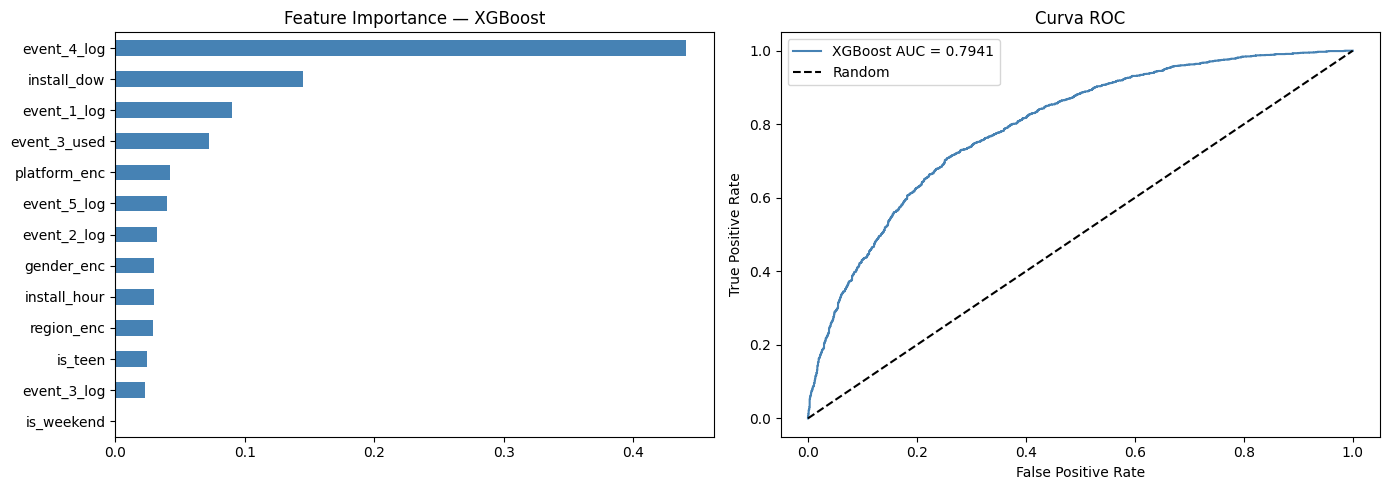

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance — XGBoost')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', label=f'XGBoost AUC = {roc_auc_score(y_test, y_prob):.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC')
axes[1].legend()

plt.tight_layout()
plt.show()

**Conclusiones del XGBoost:**

**Performance:** ROC-AUC de 0.7941 — mejor que Logistic Regression (0.7749) y Random Forest (0.7731). El boosting captura mejor las interacciones no lineales entre features.

**Feature importance:**
- `event_4_log` domina con una importancia de 0.45 — concentrada en un solo feature, lo que sugiere que este evento tiene una relación no lineal fuerte con el churn.
- `install_dow` sube al 2do puesto — el día de la semana tiene más peso de lo que la LR indicaba.
- `event_3_used` aparece 4to — valida la decisión de crear esa feature binaria en el ETL.
- `is_weekend` cae a casi cero — su información ya está capturada completamente por `install_dow`.

---
## Comparación final de modelos

In [13]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt

# Cargar modelos ya entrenados o re-entrenar
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# XGBoost ya entrenado arriba como xgb

modelos = {'Logistic Regression': lr, 'Random Forest': rf, 'XGBoost': xgb}
resultados = []

for nombre, modelo in modelos.items():
    yp = modelo.predict(X_test)
    yprob = modelo.predict_proba(X_test)[:, 1]
    rep = classification_report(y_test, yp, target_names=['Retuvo', 'Churnó'], output_dict=True)
    resultados.append({
        'Modelo': nombre,
        'ROC-AUC': round(roc_auc_score(y_test, yprob), 4),
        'F1 Retuvo': round(rep['Retuvo']['f1-score'], 2),
        'F1 Churnó': round(rep['Churnó']['f1-score'], 2),
        'Accuracy': round(rep['accuracy'], 2)
    })

pd.DataFrame(resultados).set_index('Modelo')

,ROC-AUC,F1 Retuvo,F1 Churnó,Accuracy
Modelo,,,,
Logistic Regression,0.7749,0.69,0.75,0.72
Random Forest,0.7731,0.65,0.75,0.71
XGBoost,0.7941,0.69,0.75,0.72


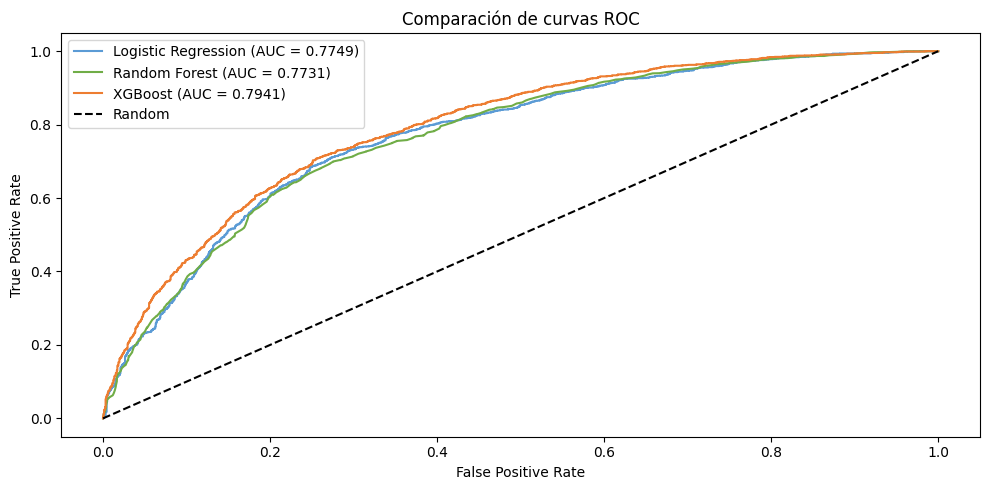

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

colores = ['#5b9bd5', '#70ad47', '#ed7d31']
for (nombre, modelo), color in zip(modelos.items(), colores):
    yprob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yprob)
    auc = roc_auc_score(y_test, yprob)
    ax.plot(fpr, tpr, color=color, label=f'{nombre} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Comparación de curvas ROC')
ax.legend()
plt.tight_layout()
plt.show()

**Cómo leer la curva ROC:**

El modelo asigna a cada usuario una **probabilidad de churn** (entre 0 y 1). Para convertir eso en una predicción binaria, se necesita un **threshold**: si la probabilidad supera ese umbral, se predice churn.

- La curva ROC muestra cómo cambian los aciertos y errores del modelo para cada threshold posible.
- **Eje X (FPR):** usuarios que retuvieron pero fueron predichos como churn (falsos positivos).
- **Eje Y (TPR):** churners reales que el modelo detectó correctamente.
- La diagonal punteada es un modelo random (AUC = 0.5). Cuanto más alejada esté la curva hacia arriba a la izquierda, mejor.

La zona izquierda importa porque representa thresholds altos — el modelo solo predice churn cuando está muy seguro. En producción, si el costo de una acción de retención es alto, se trabaja en esa zona para no desperdiciar recursos en usuarios que iban a volver solos.

El **AUC = 0.7941** significa que si tomás un churner y un retenido al azar, el modelo le asigna mayor probabilidad de churn al churner en el 79.4% de los casos.